<a href="https://colab.research.google.com/github/Fergit42/Fergit42/blob/main/series.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

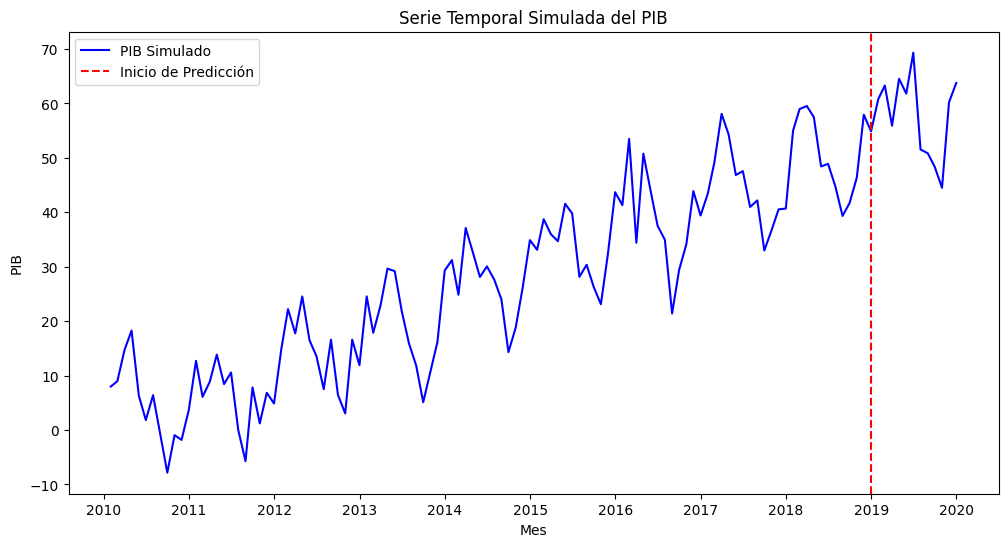

Prueba ADF: Estadístico = 0.22, p-valor = 0.97
                               SARIMAX Results                                
Dep. Variable:                    PIB   No. Observations:                  108
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -360.837
Date:                Fri, 13 Dec 2024   AIC                            727.674
Time:                        16:08:42   BIC                            735.693
Sample:                             0   HQIC                           730.925
                                - 108                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3214      0.483     -0.666      0.505      -1.267       0.625
ma.L1          0.1354      0.511      0.265      0.791      -0.867       1.138
sigma

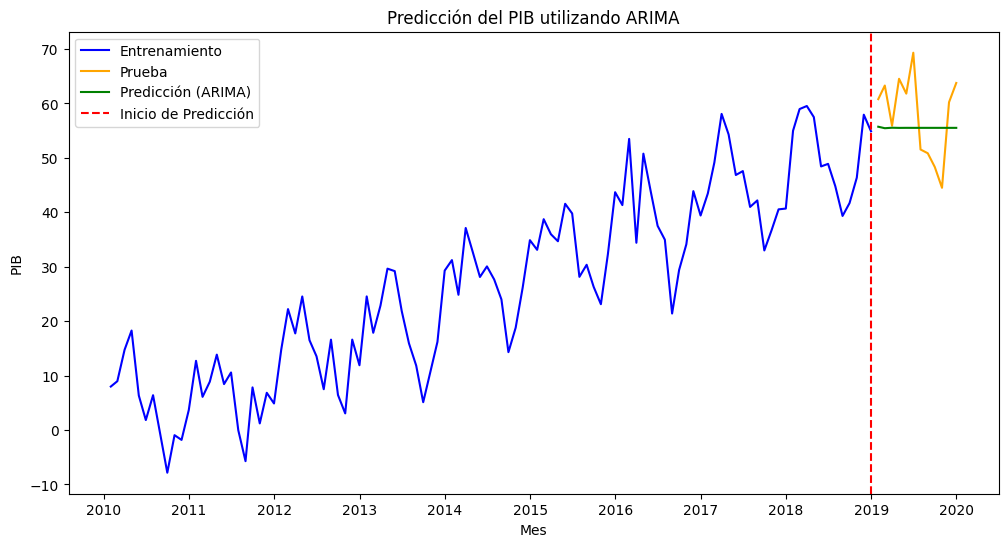

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller

# Simular datos de una serie temporal (PIB con tendencia y estacionalidad)
np.random.seed(42)
n = 120  # Número de meses
t = np.arange(1, n + 1)
trend = 0.5 * t
seasonality = 10 * np.sin(2 * np.pi * t / 12)
noise = np.random.normal(scale=5, size=n)
pib_series = trend + seasonality + noise

# Crear DataFrame con los datos simulados
data = pd.DataFrame({'Month': pd.date_range(start='2010-01', periods=n, freq='ME'),
                     'PIB': pib_series})

# Dividir en entrenamiento y prueba
train = data.iloc[:-12]
test = data.iloc[-12:]

# Visualizar la serie temporal
plt.figure(figsize=(12, 6))
plt.plot(data['Month'], data['PIB'], label='PIB Simulado', color='blue')
plt.axvline(train['Month'].iloc[-1], color='red', linestyle='--', label='Inicio de Predicción')
plt.title('Serie Temporal Simulada del PIB')
plt.xlabel('Mes')
plt.ylabel('PIB')
plt.legend()
plt.show()

# Prueba de estacionariedad (ADF)
adf_test = adfuller(train['PIB'])
print(f"Prueba ADF: Estadístico = {adf_test[0]:.2f}, p-valor = {adf_test[1]:.2f}")

# Ajustar un modelo ARIMA
model = ARIMA(train['PIB'], order=(1, 1, 1))
model_fit = model.fit()
print(model_fit.summary())

# Realizar predicciones
forecast = model_fit.forecast(steps=12)
forecast = pd.DataFrame({'Month': test['Month'], 'Predicted_PIB': forecast})

# Visualizar las predicciones
plt.figure(figsize=(12, 6))
plt.plot(train['Month'], train['PIB'], label='Entrenamiento', color='blue')
plt.plot(test['Month'], test['PIB'], label='Prueba', color='orange')
plt.plot(forecast['Month'], forecast['Predicted_PIB'], label='Predicción (ARIMA)', color='green')
plt.axvline(train['Month'].iloc[-1], color='red', linestyle='--', label='Inicio de Predicción')
plt.title('Predicción del PIB utilizando ARIMA')
plt.xlabel('Mes')
plt.ylabel('PIB')
plt.legend()
plt.show()
